## XGBoost Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
pd.options.mode.chained_assignment = None

import xgboost as xgb
root = r"C:\Users\MHMD RAGAB\Downloads\DATA\New folder\\"

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score

In [2]:
df = pd.read_pickle(root + 'Finaldata.pkl')
df.head()

,user_id,product_id,times_bought,times_reordered,order_number,order_dow,order_hour_of_day,days_since_prior_order,reordered,total_orders_x,total_reorders,total_orders_y,unique_products
0,1,196,10.0,9.0,11.0,4.0,8.0,14.0,1.0,35791,27791,59,18
1,1,10258,9.0,8.0,11.0,4.0,8.0,14.0,1.0,1946,1389,59,18
2,1,10326,1.0,0.0,11.0,4.0,8.0,14.0,0.0,5526,3603,59,18
3,1,12427,10.0,9.0,11.0,4.0,8.0,14.0,0.0,6476,4797,59,18
4,1,13032,3.0,2.0,11.0,4.0,8.0,14.0,1.0,3751,2465,59,18


In [3]:
def reduce_memory(df):
    
    """
    This function reduce the dataframe memory usage by converting it's type for easier handling.
    
    Parameters: Dataframe
    Return: Dataframe
    """
    
    start_mem_usg = df.memory_usage().sum() / 1024**2 
    print("Memory usage of properties dataframe is :",start_mem_usg," MB")
    
    for col in df.columns:
        if df[col].dtypes in ["int64", "int32", "int16"]:
            
            cmin = df[col].min()
            cmax = df[col].max()
            
            if cmin > np.iinfo(np.int8).min and cmax < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            
            elif cmin > np.iinfo(np.int16).min and cmax < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            
            elif cmin > np.iinfo(np.int32).min and cmax < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        
        if df[col].dtypes in ["float64", "float32"]:
            
            cmin = df[col].min()
            cmax = df[col].max()
            
            if cmin > np.finfo(np.float16).min and cmax < np.finfo(np.float16).max:
                df[col] = df[col].astype(np.float16)
            
            elif cmin > np.finfo(np.float32).min and cmax < np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
    
    print("")
    print("___MEMORY USAGE AFTER COMPLETION:___")
    mem_usg = df.memory_usage().sum() / 1024**2 
    print("Memory usage is: ",mem_usg," MB")
    print("This is ",100*mem_usg/start_mem_usg,"% of the initial size")
    
    return df

In [4]:
df = reduce_memory(df)

Memory usage of properties dataframe is : 840.535041809082  MB

___MEMORY USAGE AFTER COMPLETION:___
Memory usage is:  274.79038429260254  MB
This is  32.69231746735647 % of the initial size


In [12]:
import pandas as pd
import numpy as np

order_products__prior = pd.read_csv(
    r'C:\Users\MHMD RAGAB\Downloads\DATA\New folder\order_products__prior.csv'
)

In [13]:
prod_feats1 = order_products__prior.groupby('product_id').agg({
    'reordered': ['count', 'sum']
})

prod_feats1.columns = ['total_orders', 'reorder_count']
prod_feats1 = prod_feats1.reset_index()

In [14]:
prod_feats1['second_time_percent'] = (
    prod_feats1['reorder_count'] / prod_feats1['total_orders']
).fillna(0)

In [15]:
print(order_products__prior.head())

   order_id  product_id  add_to_cart_order  reordered
0         2       33120                  1          1
1         2       28985                  2          1
2         2        9327                  3          0
3         2       45918                  4          1
4         2       30035                  5          0


In [16]:
df.head()

,user_id,product_id,last_ordered_in
0,1,196,11.0
1,1,10258,11.0
2,1,10326,11.0
3,1,12427,11.0
4,1,13032,11.0


In [17]:
df.shape

(8474661, 3)

In [19]:
print(df.columns)

Index(['user_id', 'product_id', 'last_ordered_in'], dtype='object')


In [20]:
label = 'reordered'

x_cols = [col for col in df.columns if col != label]

In [25]:
print(df.columns)
print(df.shape)

Index(['user_id', 'product_id', 'last_ordered_in'], dtype='object')
(8474661, 3)


In [27]:
df = order_products__prior.copy()

In [28]:
label = 'reordered'
X = df.drop(columns=[label])
y = df[label]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, test_size = 0.25)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(24325866, 3) (24325866,)
(8108623, 3) (8108623,)


In [31]:
y_train.value_counts()

reordered
1    14344902
0     9980964
Name: count, dtype: int64

In [32]:
np.ceil(y_train.value_counts()[0]/y_train.value_counts()[1])

1.0

In [33]:
y_test.value_counts()

reordered
1    4781634
0    3326989
Name: count, dtype: int64

### XGBoost Model

In [34]:
D_train = xgb.DMatrix(X_train, label=y_train)
D_test = xgb.DMatrix(X_test, label=y_test)

In [35]:
xgb_params = {
    "objective"        :"reg:logistic",
    "eval_metric"      :"logloss",
    "eta"              :0.1,
    "max_depth"        :6,
    "min_child_weight" :10,
    "gamma"            :0.70,
    "subsample"        :0.76,
    "colsample_bytree" :0.95,
    "alpha"            :2e-05,
    "scale_pos_weight" :10,
    "lambda"           :10
}

In [37]:
import gc
gc.collect()

3027

In [38]:
import gc
gc.collect()

0

In [39]:
watchlist= [(D_train, "train")]
model = xgb.train(params=xgb_params, dtrain=D_train, num_boost_round = 80, evals = watchlist, verbose_eval = 10)

[0]	train-logloss:0.89269
[10]	train-logloss:1.02567
[20]	train-logloss:1.09356
[30]	train-logloss:1.12155
[40]	train-logloss:1.13207
[50]	train-logloss:1.13563
[60]	train-logloss:1.13678
[70]	train-logloss:1.13677
[79]	train-logloss:1.13662


In [40]:
probability = model.predict(D_test)

In [41]:
predictions = [1 if i > 0.5 else 0 for i in probability]

C:\Users\MHMD RAGAB\anaconda3\envs\myenv_cv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\MHMD RAGAB\anaconda3\envs\myenv_cv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\MHMD RAGAB\anaconda3\envs\myenv_cv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i


 Classification report : 
               precision    recall  f1-score   support

           0       0.00      0.00      0.00   3326989
           1       0.59      1.00      0.74   4781634

    accuracy                           0.59   8108623
   macro avg       0.29      0.50      0.37   8108623
weighted avg       0.35      0.59      0.44   8108623

Accuracy   Score :  0.5896974122486641
F1 Score:  0.7418989396410017
Area under curve :  0.602330847147966 



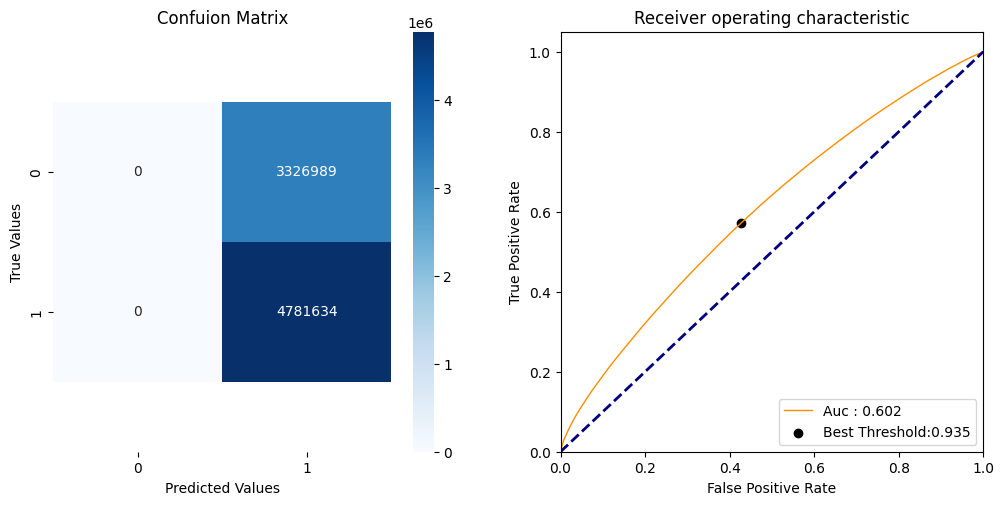

In [42]:
print ("\n Classification report : \n",classification_report(y_test, predictions))
print ("Accuracy   Score : ",accuracy_score(y_test, predictions))

#confusion matrix
conf_matrix = confusion_matrix(y_test,predictions)
plt.figure(figsize=(12,12))
plt.subplot(221)
sns.heatmap(conf_matrix, fmt = "d",annot=True, cmap='Blues')
b, t = plt.ylim()
plt.ylim(b + 0.5, t - 0.5)
plt.title('Confuion Matrix')
plt.ylabel('True Values')
plt.xlabel('Predicted Values')

#f1-score
f1 = f1_score(y_test, predictions)
print("F1 Score: ", f1)

#roc_auc_score
model_roc_auc = roc_auc_score(y_test,probability) 
print ("Area under curve : ",model_roc_auc,"\n")
fpr,tpr,thresholds = roc_curve(y_test,probability)
gmeans = np.sqrt(tpr * (1-fpr))
ix = np.argmax(gmeans)
threshold = np.round(thresholds[ix],3)

plt.subplot(222)
plt.plot(fpr, tpr, color='darkorange', lw=1, label = "Auc : %.3f" %model_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.scatter(fpr[ix], tpr[ix], marker='o', color='black', label='Best Threshold:' + str(threshold))
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

plt.show()

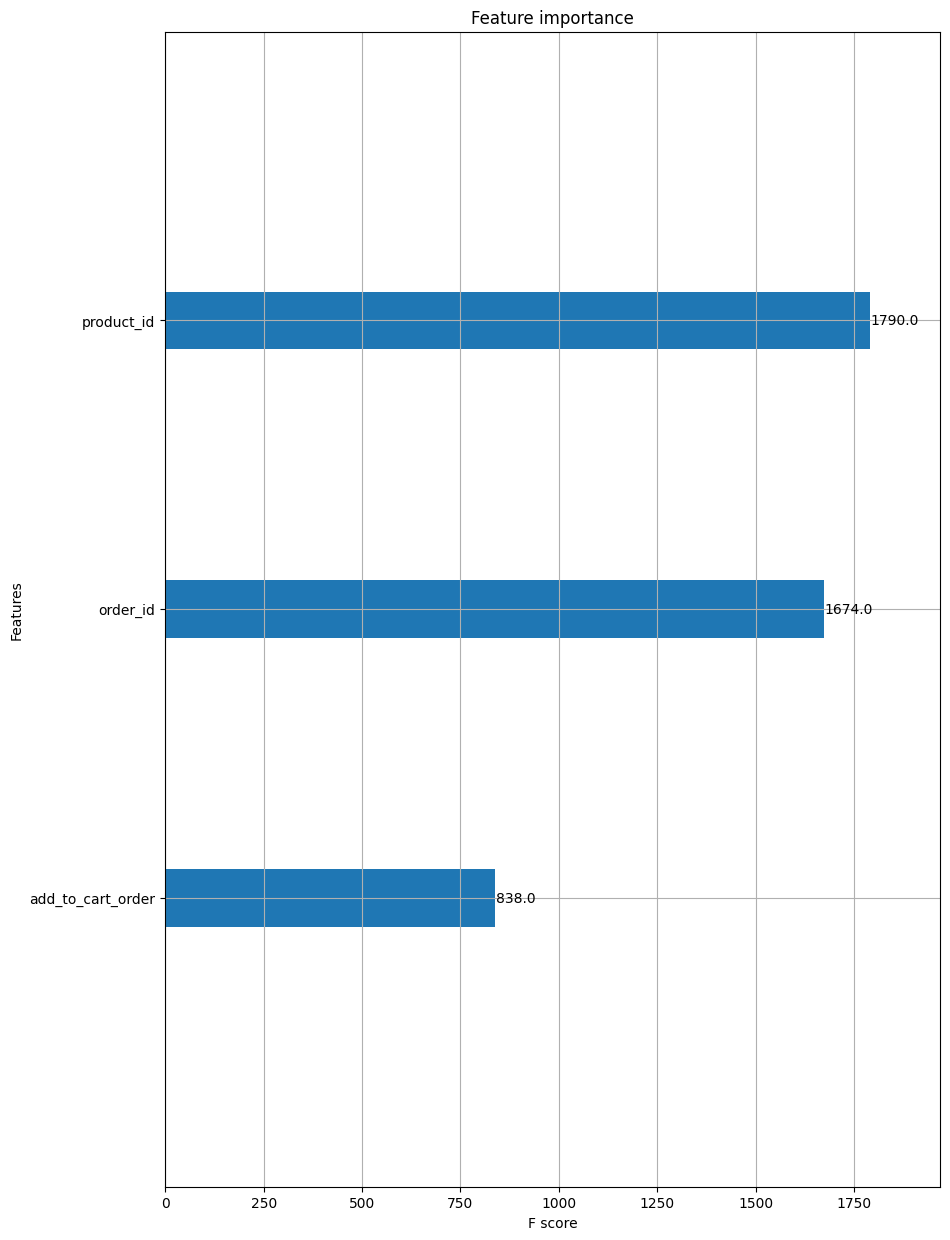

In [43]:
fig, ax = plt.subplots(figsize = (10,15))
xgb.plot_importance(model, ax = ax)
fig.savefig('XGBoost Feature Importance Plot.png')